In [1]:
import sys
sys.path.append('../')

In [2]:
%load_ext autoreload
%autoreload 2


from libs.utils.ios import path_join
from libs.visualization import plots

from libs.utils.config_loader import combine_model

In [3]:
ROOT = '../../'
PLOTS_DIR = path_join(ROOT, 'results/plots')

In [4]:
COUNTOUR_LEVELS = {"start": 0.1, "stop": 1.0, "step": 0.2,
                   "colors": "white", 
                   "linewidths": 0.6, 
                   "alpha": 0.7,      
                   "fontsize": 8,     
                   "fmt": "%.2f",     
                }
                
MODEL_DETAILS_POS = {'n_citations': (0.54, 0.36), 
                     'n_publications': (0.68, 0.55), 
                     'h_index': (0.2, 0.85)}

NON_NETWORK_SIGNALS = {'n_citations': {'config_fn': path_join(ROOT, "config/non_network/main_paper.yaml"), 
                                       'posterior_regions': [
                                                                {"x": 0.88, "y": 0.90, "label": "a"},
                                                                {"x": 0.20, "y": 0.90, "label": "b"},
                                                                {"x": 0.88, "y": 0.62, "label": "c"},
                                                            ],
                                        },
                    'n_publications': {'config_fn': path_join(ROOT, "config/non_network/poisson.yaml"), 
                                        'posterior_regions': [
                                                                {"x": 0.88, "y": 0.88, "label": "a"},
                                                                {"x": 0.88, "y": 0.12, "label": "b"},
                                                            ],
                                        },
                    'h_index': {'config_fn': path_join(ROOT, "config/non_network/power_law.yaml"), 
                                'posterior_regions': [
                                                        {"x": 0.88, "y": 0.89, "label": "a"},
                                                        {"x": 0.12, "y": 0.89, "label": "b"},
                                                    ],
                                },
                    }

FIG_WIDTH = 12


In [5]:
plots.set_paper_style()

## Network and non-network Signals (main)

/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/inference/signal.py:64: RuntimeWarning: invalid value encountered in subtract
  self.likelihood_good.log_prob(x)
/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/visualization/plots.py:1713: UserWarning: The following kwargs were not used by contour: 'rasterized'
  im = ax.contourf(
/var/folders/lj/_xkc5wfx66n7wxk15hc05rjm0000gn/T/ipykernel_147/2611486849.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


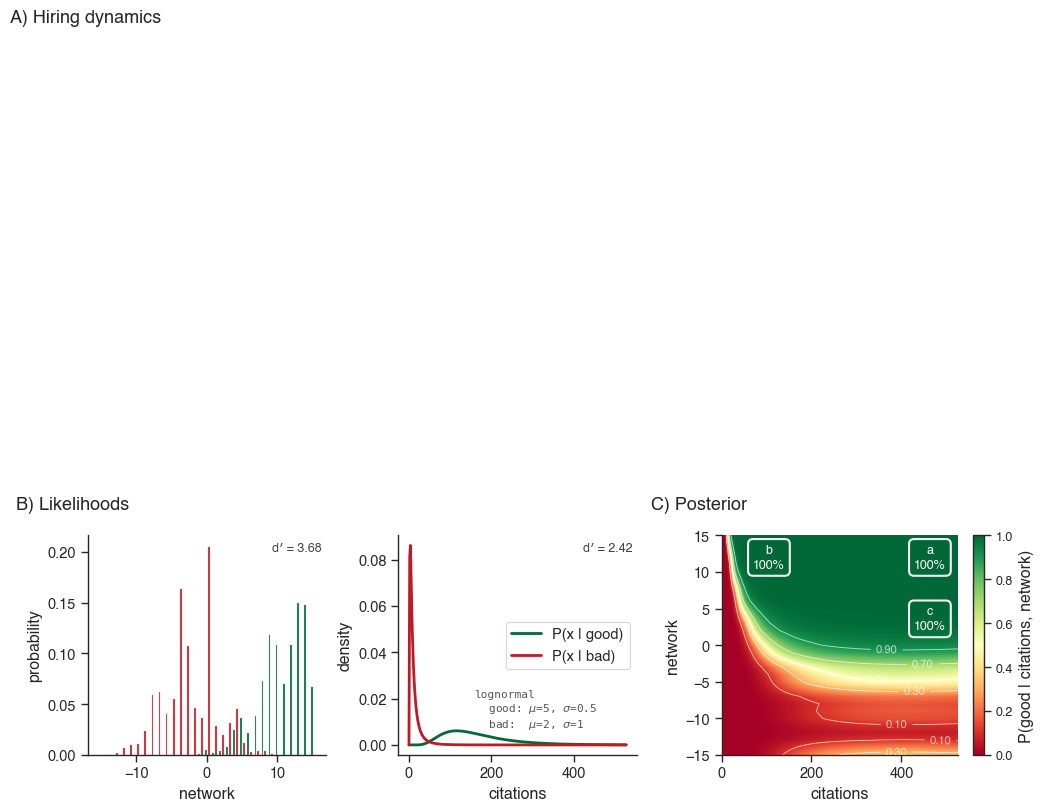

Saved figure to ../../results/plots/hiring_network_effects_non_network_posterior.pdf


In [6]:
prior = 0.35
non_network_signal = 'n_citations'
network_signal = 'referral_quality'
model_rectrust_powerlaw = combine_model(prior, 
                                        network=path_join(ROOT, "config/network/main_paper.yaml"), 
                                        non_network=NON_NETWORK_SIGNALS[non_network_signal]['config_fn'])

# w, h = 4.2, 3

fig, panels = plots.create_panel_figure(
    [[3], [2, 1]],
    figsize=(FIG_WIDTH, 2 + 7),
    inner_sharey=False,
    width_ratios=[None, [0.65, 0.35]],
    height_ratios=[0.62, 0.38],
    wspace=0.2,
    inner_wspace=0.3,
    panel_labels=['A) Hiring dynamics', 'B) Likelihoods',  'C) Posterior'],
    label_offset=(-0.3, 1.1),
    label_fontsize=13,
    label_fontweight='bold',
)

model = model_rectrust_powerlaw

# panel a (hiring dynamics)
fn_diagram = path_join(ROOT, 'results/plots/hiring_network_effects_non_network_v1.6.pdf')
plots.embed_pdf_in_panel(fig, panels[0], fn_diagram, scale=1.15, dx=-0.1, dy=-0.09)


# panel b (likelihoods)
for col, signal in enumerate(model.signals.values()):

    ax = panels[1][col]
    aesthetics={'title': None,
                'show_xlabel': True,
                'xlabel': signal,
                'show_legend': col != 0,
                # 'loglog': signal.name in ['n_citations'],
                'model_details_pos': (0.32, 0.3) if signal.name == 'n_citations' else None,
                }
    _ = plots.plot_signal_distributions(ax=ax, signal=signal, aesthetics=aesthetics)
    
aesthetics={'title': None,
            'xlabel': model.signals[non_network_signal],
            'ylabel': model.signals[network_signal],
            # 'logx': True,
            }

# panel c (posterior)
ax = panels[2][0]
_ = plots.plot_posterior_heatmap_network_nonnetwork(ax=ax, 
                model=model, 
                aesthetics=aesthetics,
                gaussian_sigma=1.2,
                contour_levels=COUNTOUR_LEVELS,
                posterior_regions=NON_NETWORK_SIGNALS[non_network_signal]['posterior_regions'],
                )

fig.tight_layout()
fn = path_join(PLOTS_DIR, 'hiring_network_effects_non_network_posterior.pdf')
plots.save_fig(fig, fn)

## Network Signals

/var/folders/lj/_xkc5wfx66n7wxk15hc05rjm0000gn/T/ipykernel_147/152068305.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


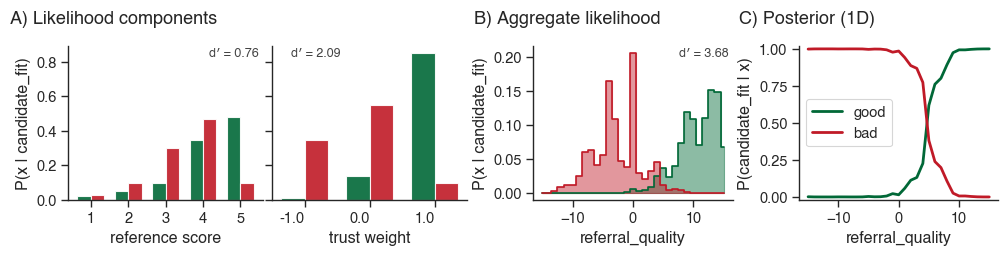

Saved figure to ../../results/plots/referral_quality_breakdown.pdf


In [7]:
prior = 0.35
non_network_signal = 'n_citations'
network_signal = 'referral_quality'

model_rectrust_powerlaw = combine_model(prior, 
                                        network=path_join(ROOT, "config/network/main_paper.yaml"), 
                                        non_network=NON_NETWORK_SIGNALS[non_network_signal]['config_fn'])

model = model_rectrust_powerlaw
signal_name = network_signal

fig, panels = plots.create_panel_figure(
    [2, 1, 1],
    figsize=(FIG_WIDTH, 2.),
    inner_sharey=True,
    width_ratios=[0.50, 0.25, 0.25],
    wspace=0.25,
    inner_wspace=0.05,
    panel_labels=['A) Likelihood components', 'B) Aggregate likelihood',  'C) Posterior (1D)'],
    label_offset=(-0.3, 1.12),
    label_fontsize=13,
    label_fontweight='bold',
)

signal = model.signals[signal_name]

aesthetics_signals_first = {'title': None, 'ylabel': "P(x | candidate_fit)", 'show_legend':False, 'show_dprime':True, 'dprime_pos': (0.98, 0.99)}
aesthetics_signals_second = {'title': None, 'show_ylabel':False, 'show_legend':False, 'show_dprime':True, 'dprime_pos': (0.35, 0.99)}
aesthetics_likelihood = {'title': None, 'ylabel': "P(x | candidate_fit)", 'xlabel': network_signal, 'show_legend':False, 'dprime_pos': (0.98, 0.99), }
aesthetics_posterior = {'title': None, 'ylabel': "P(candidate_fit | x)", 'show_legend':True, 'xlabel': network_signal, 'simple_legend':True, 'legend_loc': 'center left'}

# Signals
_ = plots.plot_reference_signal_breakdown_score(signal=signal, ax=panels[0][0], aesthetics=aesthetics_signals_first)
_ = plots.plot_reference_signal_breakdown_trust(signal=signal, ax=panels[0][1], aesthetics=aesthetics_signals_second)

# likelihood
_ = plots.plot_reference_signal_breakdown_aggregate(signal=signal, ax=panels[1][0], aesthetics=aesthetics_likelihood)

# posterior
_ = plots.plot_posterior_vs_signal(model, signal_name=signal_name, n_points=300, ax=panels[2][0], aesthetics=aesthetics_posterior)

fig.tight_layout()
fn = path_join(PLOTS_DIR, 'referral_quality_breakdown.pdf')
plots.save_fig(fig, fn)

## Non-network signals

### Publications

/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/inference/signal.py:64: RuntimeWarning: invalid value encountered in subtract
  self.likelihood_good.log_prob(x)
/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/visualization/plots.py:1713: UserWarning: The following kwargs were not used by contour: 'rasterized'
  im = ax.contourf(
/var/folders/lj/_xkc5wfx66n7wxk15hc05rjm0000gn/T/ipykernel_147/1609099396.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


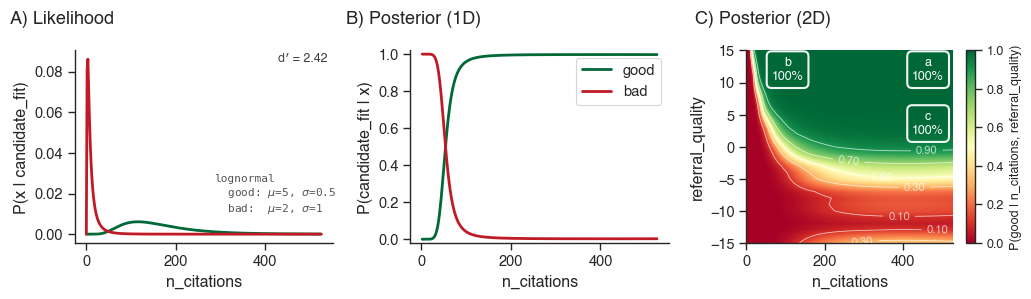

Saved figure to ../../results/plots/n_citations_likelihood_and_posteriors.pdf


/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/visualization/plots.py:1713: UserWarning: The following kwargs were not used by contour: 'rasterized'
  im = ax.contourf(
/var/folders/lj/_xkc5wfx66n7wxk15hc05rjm0000gn/T/ipykernel_147/1609099396.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


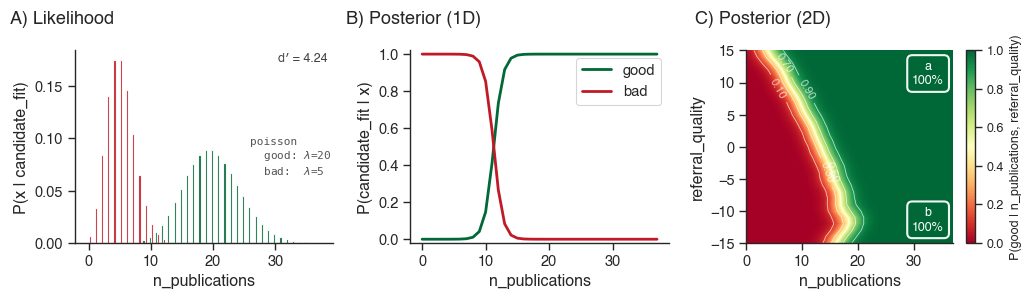

Saved figure to ../../results/plots/n_publications_likelihood_and_posteriors.pdf


/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/visualization/plots.py:1713: UserWarning: The following kwargs were not used by contour: 'rasterized'
  im = ax.contourf(
/var/folders/lj/_xkc5wfx66n7wxk15hc05rjm0000gn/T/ipykernel_147/1609099396.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


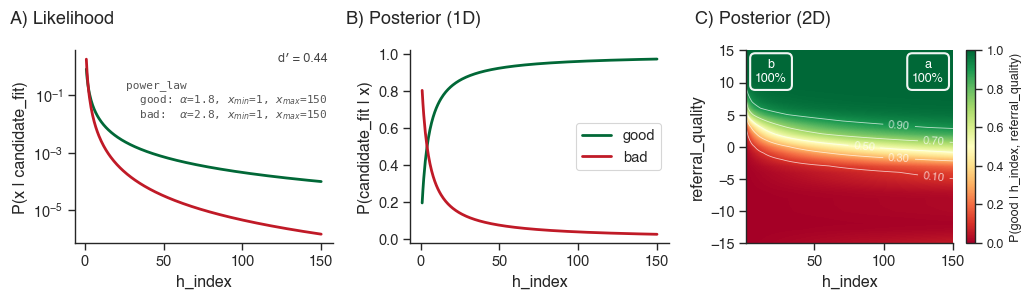

Saved figure to ../../results/plots/h_index_likelihood_and_posteriors.pdf


In [8]:
prior = 0.35
                
for signal_name, obj in NON_NETWORK_SIGNALS.items():
    
    model = combine_model(prior, 
                          network=path_join(ROOT, "config/network/main_paper.yaml"), 
                          non_network=obj['config_fn'])

    fig, panels = plots.create_panel_figure(
        [1, 1, 1],
        figsize=(FIG_WIDTH, 2.5),
        inner_sharey=True,
        width_ratios=[0.33, 0.33, 0.33],
        wspace=0.3,
        inner_wspace=0.05,
        panel_labels=['A) Likelihood', 'B) Posterior (1D)',  'C) Posterior (2D)'],
        label_offset=(-0.25, 1.12),
        label_fontsize=13,
        label_fontweight='bold',
    )

    signal = model.signals[signal_name]
    
    aesthetics_likelihood = {'title': None, 'ylabel': "P(x | candidate_fit)", 'show_legend':False, 
                             'model_details_pos': MODEL_DETAILS_POS[signal_name],
                             'dprime_pos': (0.98, 0.99), 
                             'logy':signal_name in ['h_index'],
                             }
    aesthetics_posterior_1d = {'title': None, 'ylabel': "P(candidate_fit | x)", 'show_legend':True, 'simple_legend':True}
    aesthetics_posterior_2d = {'title': None, 'cbar_use_names':True, 'cbar_fontsize':9}


    # Likelihood
    _ = plots.plot_signal_distributions(signal=signal, ax=panels[0][0], aesthetics=aesthetics_likelihood)

    # Posterior 1d
    _ = plots.plot_posterior_vs_signal(model, signal_name=signal_name, n_points=300, ax=panels[1][0], aesthetics=aesthetics_posterior_1d)

    # Posterior 2d
    _ = plots.plot_posterior_heatmap_network_nonnetwork(model=model, ax=panels[2][0], 
                                                        gaussian_sigma=1.2, 
                                                        contour_levels=COUNTOUR_LEVELS,
                                                        posterior_regions=obj['posterior_regions'],
                                                        aesthetics=aesthetics_posterior_2d)

    fig.tight_layout()
    fn = path_join(PLOTS_DIR, f'{signal_name}_likelihood_and_posteriors.pdf')
    plots.save_fig(fig, fn)

/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/inference/signal.py:64: RuntimeWarning: invalid value encountered in subtract
  self.likelihood_good.log_prob(x)
/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/visualization/plots.py:1713: UserWarning: The following kwargs were not used by contour: 'rasterized'
  im = ax.contourf(
/var/folders/lj/_xkc5wfx66n7wxk15hc05rjm0000gn/T/ipykernel_147/758856618.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


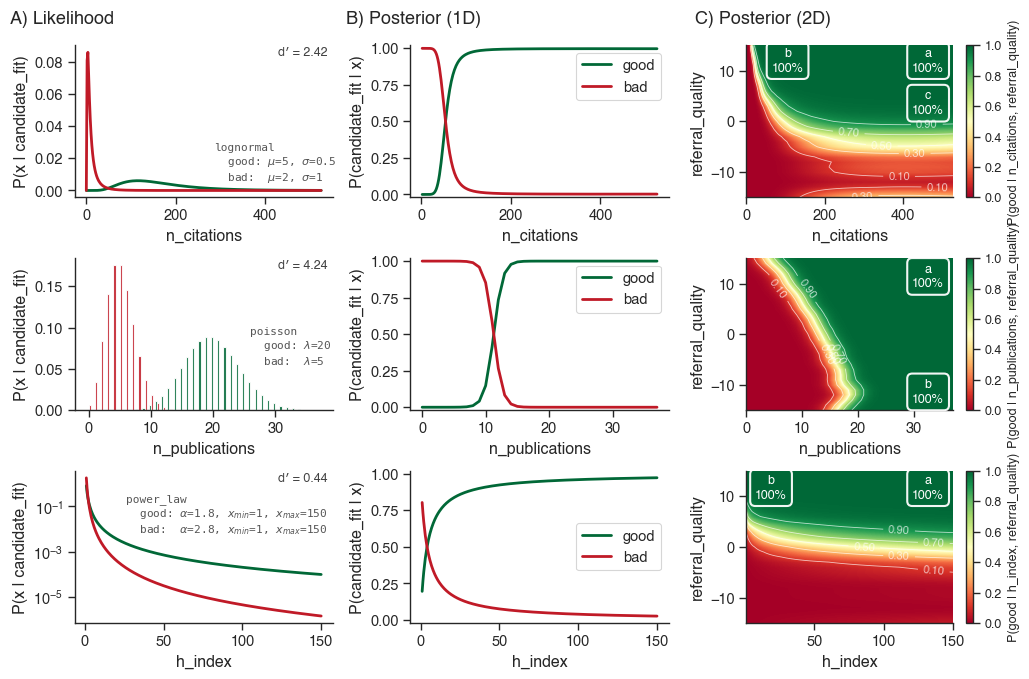

Saved figure to ../../results/plots/all_likelihood_and_posteriors.pdf


In [9]:
prior = 0.35


fig, panels = plots.create_panel_figure(
        [(3, 1), (3, 1), (3, 1)],
        figsize=(FIG_WIDTH, 2.5 * 3),
        # inner_sharey=True,
        # width_ratios=[0.33, 0.33, 0.33],
        wspace=0.3,
        hspace=0.2,
        inner_wspace=0.05,
        inner_hspace=0.4,
        panel_labels=['A) Likelihood', 'B) Posterior (1D)',  'C) Posterior (2D)'],
        label_offset=(-0.25, 1.12),
        label_fontsize=13,
        label_fontweight='bold',
    )

for row_id, (signal_name, obj) in enumerate(NON_NETWORK_SIGNALS.items()):
    
    model = combine_model(prior, 
                          network=path_join(ROOT, "config/network/main_paper.yaml"), 
                          non_network=obj['config_fn'])
    signal = model.signals[signal_name]
    
    aesthetics_likelihood = {'title': None, 'ylabel': f"P(x | candidate_fit)", 'show_legend':False, 
                             'model_details_pos': MODEL_DETAILS_POS[signal_name],
                             'dprime_pos': (0.98, 0.99), 
                             'logy':signal_name in ['h_index'],
                             }
    aesthetics_posterior_1d = {'title': None, 'ylabel': f"P(candidate_fit | x)", 'show_legend':True, 'simple_legend':True}
    aesthetics_posterior_2d = {'title': None, 'cbar_use_names':True, 'cbar_fontsize':9}


    # Likelihood
    _ = plots.plot_signal_distributions(signal=signal, ax=panels[0][row_id], aesthetics=aesthetics_likelihood)

    # Posterior 1d
    _ = plots.plot_posterior_vs_signal(model, signal_name=signal_name, n_points=300, ax=panels[1][row_id], aesthetics=aesthetics_posterior_1d)

    # Posterior 2d
    _ = plots.plot_posterior_heatmap_network_nonnetwork(model=model, ax=panels[2][row_id], 
                                                        gaussian_sigma=1.2, 
                                                        contour_levels=COUNTOUR_LEVELS,
                                                        posterior_regions=obj['posterior_regions'],
                                                        aesthetics=aesthetics_posterior_2d)

fig.tight_layout()
fn = path_join(PLOTS_DIR, f'all_likelihood_and_posteriors.pdf')
plots.save_fig(fig, fn)